# Load Dataset

In [1]:
data <- read.csv("../Pima-Indians-Diabetes-Dataset/diabetes.csv")
head(data)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


In [2]:
sum(data$SkinThickness == 0)

[1] 227

In [3]:
Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)
garnet <- "#6B0D0E"
gold   <- "#F8C23A"

In [4]:
train_data <- read.csv("train_data.csv")
test_data <- read.csv("test_data.csv")

In [5]:
dim(train_data)
dim(test_data)

[1] 614   9

[1] 154   9

In [6]:
head(train_data)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,0,138,60,35,167,34.6,0.534,21,1
2,8,74,70,40,49,35.3,0.705,39,0
3,5,143,78,0,0,45.0,0.190,47,0
4,3,87,60,18,0,21.8,0.444,21,0
5,8,85,55,20,0,24.4,0.136,42,0
6,5,78,48,0,0,33.7,0.654,25,0


# Handle Missing Value
* *Glucose*
* *BloodPressure*
* *SkinThickness*
* *Insulin*
* *BMI*

## Median

In [7]:
summary(train_data)

  Pregnancies        Glucose      BloodPressure    SkinThickness  
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.:100.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :118.0   Median : 70.00   Median :23.00  
 Mean   : 3.793   Mean   :121.5   Mean   : 68.66   Mean   :20.79  
 3rd Qu.: 6.000   3rd Qu.:140.0   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :110.00   Max.   :99.00  
    Insulin            BMI        DiabetesPedigreeFunction      Age       
 Min.   :  0.00   Min.   : 0.00   Min.   :0.0780           Min.   :21.00  
 1st Qu.:  0.00   1st Qu.:27.32   1st Qu.:0.2482           1st Qu.:24.00  
 Median : 41.00   Median :32.00   Median :0.3825           Median :29.00  
 Mean   : 81.63   Mean   :31.97   Mean   :0.4839           Mean   :33.18  
 3rd Qu.:130.00   3rd Qu.:36.58   3rd Qu.:0.6400           3rd Qu.:40.00  
 Max.   :846.00   Max.   :67.10   Max.   :2.4200           Max.   :81.00  
    Ou

### Calculate Median

In [8]:
# Glucose
median_glucose_0 <- median(train_data$Glucose[
  train_data$Outcome == 0 &
  train_data$Glucose != 0
], na.rm = TRUE)

median_glucose_1 <- median(train_data$Glucose[
  train_data$Outcome == 1 &
  train_data$Glucose != 0
], na.rm = TRUE)


# BloodPressure
median_bp_0 <- median(train_data$BloodPressure[
  train_data$Outcome == 0 &
  train_data$BloodPressure != 0
], na.rm = TRUE)

median_bp_1 <- median(train_data$BloodPressure[
  train_data$Outcome == 1 &
  train_data$BloodPressure != 0
], na.rm = TRUE)


# SkinThickness
median_skin_0 <- median(train_data$SkinThickness[
  train_data$Outcome == 0 &
  train_data$SkinThickness != 0
], na.rm = TRUE)

median_skin_1 <- median(train_data$SkinThickness[
  train_data$Outcome == 1 &
  train_data$SkinThickness != 0
], na.rm = TRUE)


# Insulin
median_insulin_0 <- median(train_data$Insulin[
  train_data$Outcome == 0 &
  train_data$Insulin != 0
], na.rm = TRUE)

median_insulin_1 <- median(train_data$Insulin[
  train_data$Outcome == 1 &
  train_data$Insulin != 0
], na.rm = TRUE)


# BMI
median_bmi_0 <- median(train_data$BMI[
  train_data$Outcome == 0 &
  train_data$BMI != 0
], na.rm = TRUE)

median_bmi_1 <- median(train_data$BMI[
  train_data$Outcome == 1 &
  train_data$BMI != 0
], na.rm = TRUE)

In [9]:
median_glucose_0
median_glucose_1

median_bp_0
median_bp_1

median_skin_0
median_skin_1

median_insulin_0
median_insulin_1

median_bmi_0
median_bmi_1

[1] 108

[1] 141

[1] 70

[1] 74

[1] 27

[1] 32

[1] 95

[1] 169.5

[1] 30

[1] 34.3

### Impute with Mean

In [10]:
# Glucose
train_data$Glucose[
  train_data$Outcome == 0 &
  train_data$Glucose == 0
] <- median_glucose_0

train_data$Glucose[
  train_data$Outcome == 1 &
  train_data$Glucose == 0
] <- median_glucose_1


# BloodPressure
train_data$BloodPressure[
  train_data$Outcome == 0 &
  train_data$BloodPressure == 0
] <- median_bp_0

train_data$BloodPressure[
  train_data$Outcome == 1 &
  train_data$BloodPressure == 0
] <- median_bp_1


# SkinThickness
train_data$SkinThickness[
  train_data$Outcome == 0 &
  train_data$SkinThickness == 0
] <- median_skin_0

train_data$SkinThickness[
  train_data$Outcome == 1 &
  train_data$SkinThickness == 0
] <- median_skin_1


# Insulin
train_data$Insulin[
  train_data$Outcome == 0 &
  train_data$Insulin == 0
] <- median_insulin_0

train_data$Insulin[
  train_data$Outcome == 1 &
  train_data$Insulin == 0
] <- median_insulin_1


# BMI
train_data$BMI[
  train_data$Outcome == 0 &
  train_data$BMI == 0
] <- median_bmi_0

train_data$BMI[
  train_data$Outcome == 1 &
  train_data$BMI == 0
] <- median_bmi_1

### Use Same median to impute Testing Set

In [11]:
# Glucose
test_data$Glucose[
  test_data$Outcome == 0 &
  test_data$Glucose == 0
] <- median_glucose_0

test_data$Glucose[
  test_data$Outcome == 1 &
  test_data$Glucose == 0
] <- median_glucose_1

# BloodPressure
test_data$BloodPressure[
  test_data$Outcome == 0 &
  test_data$BloodPressure == 0
] <- median_bp_0

test_data$BloodPressure[
  test_data$Outcome == 1 &
  test_data$BloodPressure == 0
] <- median_bp_1

# SkinThickness
test_data$SkinThickness[
  test_data$Outcome == 0 &
  test_data$SkinThickness == 0
] <- median_skin_0

test_data$SkinThickness[
  test_data$Outcome == 1 &
  test_data$SkinThickness == 0
] <- median_skin_1

# Insulin
test_data$Insulin[
  test_data$Outcome == 0 &
  test_data$Insulin == 0
] <- median_insulin_0

test_data$Insulin[
  test_data$Outcome == 1 &
  test_data$Insulin == 0
] <- median_insulin_1

# BMI
test_data$BMI[
  test_data$Outcome == 0 &
  test_data$BMI == 0
] <- median_bmi_0

test_data$BMI[
  test_data$Outcome == 1 &
  test_data$BMI == 0
] <- median_bmi_1

In [12]:
model_median <- glm(Outcome ~., data = train_data, family = binomial)
summary(model_median)


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_data)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -9.078071   0.920045  -9.867  < 2e-16 ***
Pregnancies               0.113248   0.036133   3.134 0.001723 ** 
Glucose                   0.031348   0.004455   7.037 1.97e-12 ***
BloodPressure            -0.006782   0.009943  -0.682 0.495191    
SkinThickness             0.033842   0.015186   2.228 0.025850 *  
Insulin                   0.005736   0.001647   3.482 0.000497 ***
BMI                       0.060298   0.020284   2.973 0.002952 ** 
DiabetesPedigreeFunction  0.606244   0.326713   1.856 0.063513 .  
Age                       0.012463   0.010789   1.155 0.248052    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 549.35  on 605  degrees of freedom
AIC: 567.

In [13]:
prob <- predict(
    model_median,
    newdata = test_data,
    type = "response"
)
pred <- ifelse(prob > 0.5, 1, 0)
conf_matrix <- table(
    Predicted = pred, 
    Actual = test_data$Outcome
)

conf_matrix

         Actual
Predicted  0  1
        0 89 22
        1 13 30

In [14]:
TP <- conf_matrix["1","1"]
TN <- conf_matrix["0","0"]
FP <- conf_matrix["1","0"]
FN <- conf_matrix["0","1"]

accuracy <- (TP + TN) / sum(conf_matrix)

precision <- TP / (TP + FP)

recall <- TP / (TP + FN)

f1 <- 2 * precision * recall /
      (precision + recall)

cat("\nAccuracy :", round(accuracy, 4))
cat("\nPrecision:", round(precision, 4))
cat("\nRecall   :", round(recall, 4))
cat("\nF1 Score :", round(f1, 4))


Accuracy : 0.7727
Precision: 0.6977
Recall   : 0.5769
F1 Score : 0.6316

In [16]:
BIC(model_median)

[1] 607.1305

# PCA + Logistic Regression

### Split X and Y

In [ ]:
train_x <- subset(train_data, select = -Outcome)
train_y <- train_data$Outcome

test_x <- subset(test_data, select = -Outcome)
test_y <- test_data$Outcome

### Z-Score Scaling

In [ ]:
# Calculate mean and sd from TRAINING DATA ONLY
train_mean <- apply(train_x, 2, mean)
train_sd <- apply(train_x, 2, sd)

In [ ]:
# Scale training data
train_scaled <- scale(
  train_x,
  center = train_mean,
  scale = train_sd
)

In [ ]:
# Scale testing data using TRAINING statistics
test_scaled <- scale(
  test_x,
  center = train_mean,
  scale = train_sd
)

### PCA

In [ ]:
pca_model <- prcomp(
  train_scaled,
  center = FALSE,
  scale. = FALSE
)

# Variance explained
summary(pca_model)

Importance of components:
                          PC1    PC2    PC3    PC4    PC5     PC6     PC7
Standard deviation     1.5435 1.2268 1.0633 0.9479 0.8699 0.70792 0.67157
Proportion of Variance 0.2978 0.1881 0.1413 0.1123 0.0946 0.06264 0.05638
Cumulative Proportion  0.2978 0.4859 0.6272 0.7396 0.8342 0.89680 0.95318
                           PC8
Standard deviation     0.61202
Proportion of Variance 0.04682
Cumulative Proportion  1.00000

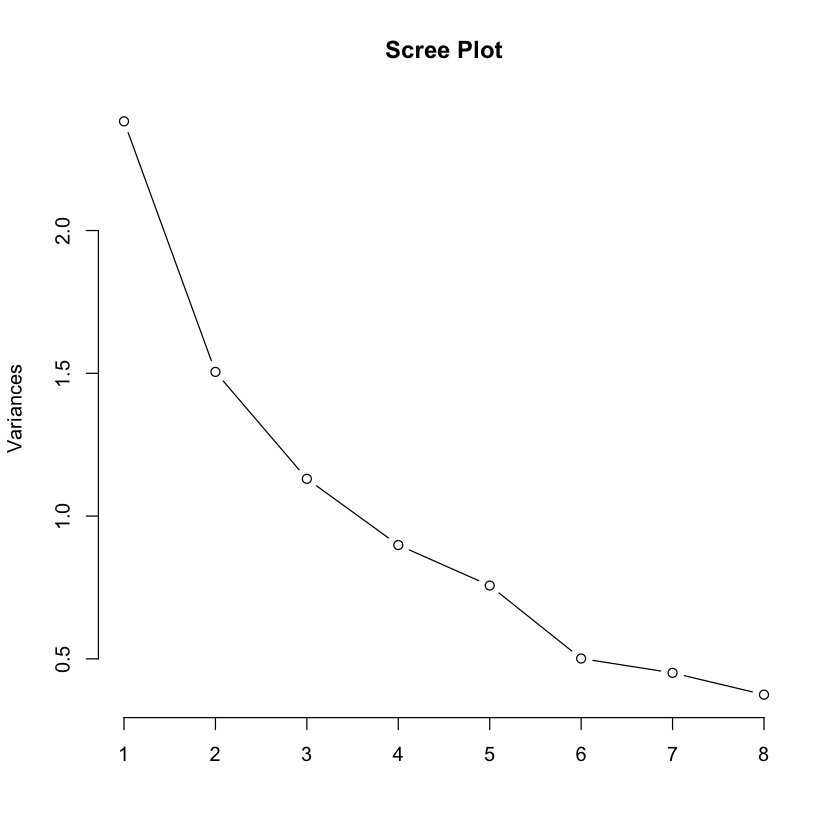

In [ ]:
# Scree Plot
par (bg = "White")
plot(
  pca_model,
  type = "l",
  main = "Scree Plot"
)

### Transform Data

In [ ]:
train_pca <- predict(
  pca_model,
  newdata = train_scaled
)

test_pca <- predict(
  pca_model,
  newdata = test_scaled
)

### Select First 5 PCs

In [ ]:
num_pc <- 5

train_pca_df <- data.frame(
  train_pca[, 1:num_pc],
  Outcome = train_y
)

test_pca_df <- data.frame(
  test_pca[, 1:num_pc]
)


### Logistic Regression

In [ ]:
model <- glm(
  Outcome ~ .,
  data = train_pca_df,
  family = binomial
)

summary(model)


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_pca_df)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  188.740     18.062  10.449  < 2e-16 ***
PC1           27.985      2.653  10.548  < 2e-16 ***
PC2           -8.073      1.028  -7.852 4.09e-15 ***
PC3          -27.006      3.213  -8.405  < 2e-16 ***
PC4          -19.296      2.130  -9.058  < 2e-16 ***
PC5            0.874      1.141   0.766    0.444    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 553.78  on 608  degrees of freedom
AIC: 565.78

Number of Fisher Scoring iterations: 5


### Prediction

In [ ]:
prob <- predict(
  model,
  newdata = test_pca_df,
  type = "response"
)

pred <- ifelse(prob > 0.5, 1, 0)

In [ ]:
cm <- table(
  Actual = test_y,
  Predicted = pred
)

cm

      Predicted
Actual  0  1
     0 88 14
     1 20 32

In [ ]:
accuracy <- sum(diag(cm)) / sum(cm)

precision <- cm["1","1"] /
             (cm["0","1"] + cm["1","1"])

recall <- cm["1","1"] /
          (cm["1","0"] + cm["1","1"])

f1 <- 2 * precision * recall /
      (precision + recall)

cat("Accuracy =", round(accuracy,4), "\n")
cat("Precision =", round(precision,4), "\n")
cat("Recall =", round(recall,4), "\n")
cat("F1 Score =", round(f1,4), "\n")

Accuracy = 0.7792 
Precision = 0.6957 
Recall = 0.6154 
F1 Score = 0.6531 
